In [1]:
import sys

sys.path.append("../../..")
from setup_figs import clean_names, pd, sns, plt, np

In [2]:
hue_order = [
    "Subj. num.",
    "Attachment site",
    "Relative clause type",
    "Obj. num.",
    "Verb freq.",
    "(Obj. freq. x Embed. freq.)",
    "Embed. num.",
]

In [3]:
scores = clean_names(pd.read_parquet("0.parquet"))
scores = scores[scores.Feature.isin(hue_order)]
colors = sns.color_palette("tab10")

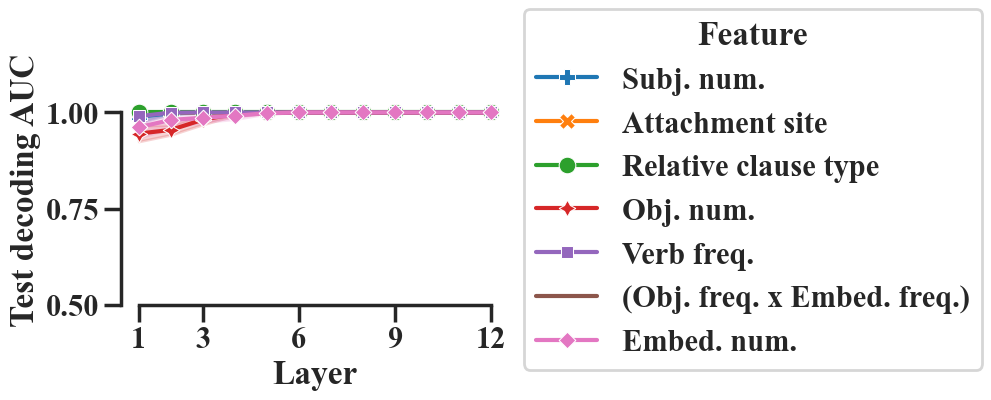

In [4]:
plt.figure(figsize=(5, 3))
ax = sns.lineplot(
    scores,
    x="representations.layer",
    y="mean",
    hue="Feature",
    hue_order=hue_order,
    style="Feature",
    markers=True,
    dashes=False,
    palette=colors,
)

for feature, color in zip(hue_order, colors):
    group = scores[scores.Feature == feature]
    ax.fill_between(
        group["representations.layer"],
        (group["mean"] - group["std"]).clip(0, 1),
        (group["mean"] + group["std"]).clip(0, 1),
        alpha=0.2,
        step=None,
        color=color,
    )

ax.set_xlabel("Layer")
ax.set_ylim(0.5, 1.1)
ax.set_ylabel("Test decoding AUC")
ax.set_xticks([1, 3, 6, 9, 12])
sns.despine(trim=True)
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), title="Feature")
plt.savefig(
    "../../../paper/figs/BERT_RC_mean/baselines/decoding.pdf", bbox_inches="tight"
)
plt.show()